# M4: Smooth-transition VAR (STVAR) with VIX regime

The linear models in M2/M3 pool one set of coefficients across calm and
stress periods. The paper's hypothesis — soft data matters *more in hard
times* — is fundamentally about regime-dependent dynamics, which a linear
model cannot represent. The STVAR lets the dynamics shift smoothly
between a low-stress and a high-stress regime as a logistic function of
the VIX.

**Model** (`models/stvar.py`):
$$ y_t = [W_t,\; G(z_{t-1})\,W_t]\,B + \delta D_t + \varepsilon_t,\qquad G(z)=\frac{1}{1+e^{-\gamma(z-c)}} $$
with $W_t=[1,y_{t-1},\dots,y_{t-p}]$, $z$ the standardized VIX (exogenous,
lagged), and $D_t$ the COVID dummy.

Two design choices learned the hard way:
- **VIX is exogenous.** Putting it in the endogenous block makes the
  system forecast VIX, which feeds back into the regime weight and the
  iteration diverges.
- **Frozen-regime forecasting.** Future VIX is unknown, so the regime
  weight is held at its origin value $G(z_T)$ across the horizon
  (Auerbach--Gorodnichenko convention). A forecast made in a high-VIX
  month therefore uses high-stress dynamics throughout.

Inputs load from disk; no FRED calls.

In [1]:
import warnings
warnings.simplefilter('ignore')

import sys, pickle
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from load_config import load_config
from evaluation.feature_frame import build_feature_frame
from evaluation.gw import gw_test
from models.stvar import STVAR

ROOT = Path.cwd().parent
cfg = load_config(str(ROOT / 'configs/us.yaml'), secrets_path=str(ROOT / 'config.yaml'))
with open(ROOT / 'data/cache/inputs.pkl', 'rb') as f:
    d = pickle.load(f)
cubes, static = d['cubes'], d['static']

vix_m = static['VIXCLS'].copy(); vix_m.index = pd.to_datetime(vix_m.index)
vix_m = vix_m.resample('MS').mean()

BANDS = [(pd.Timestamp('2001-03-01'), pd.Timestamp('2001-11-01')),
         (pd.Timestamp('2007-12-01'), pd.Timestamp('2009-06-01')),
         (pd.Timestamp('2020-02-01'), pd.Timestamp('2020-04-01'))]

## 1. The transition function

Fit the STVAR on the full long-window sample and plot the regime weight
$G(z_{t-1})$ over time, alongside the VIX. $G\to1$ marks the high-stress
regime.

STVAR(p=4, n_endog=6, gamma=12.0, c=2.0, G_origin=0.000)


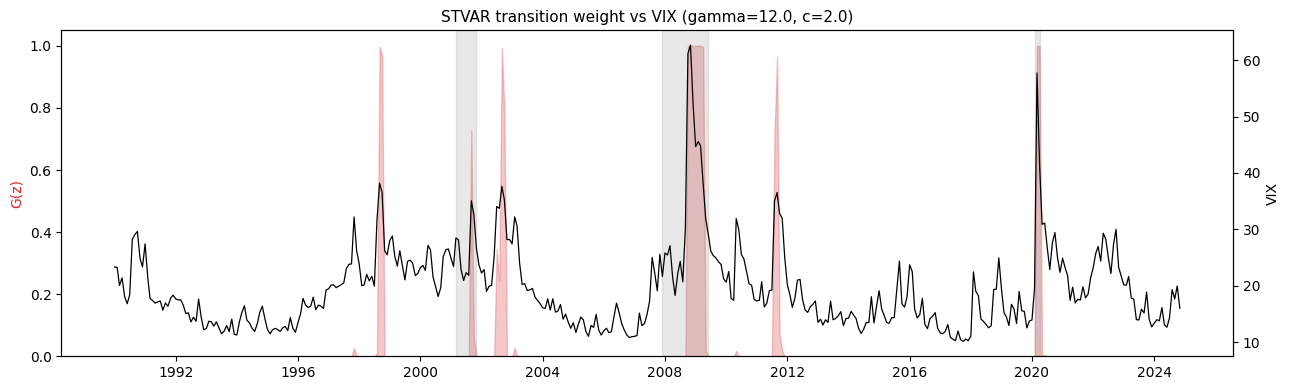

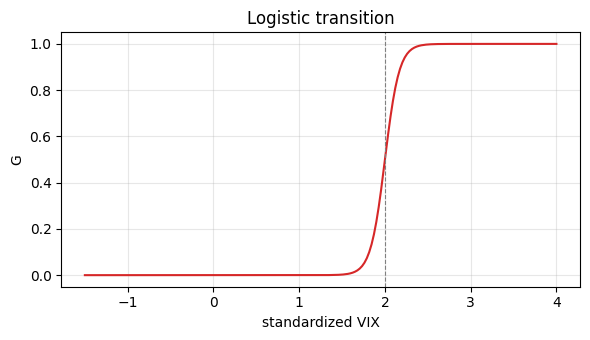

In [2]:
HARD = ['unemployment','industrial_production','payrolls','core_pce','ffr','gs10']
VARS = HARD + ['vix']
full = build_feature_frame(cfg, cubes, static, pd.Timestamp('2025-01-01'), variables=VARS).dropna(how='any')
m = STVAR(lags=4, transition_var='vix').fit(full, list(full.columns))
print(m)
G = m.transition_weights(full)

fig, ax1 = plt.subplots(figsize=(13, 4))
ax1.fill_between(G.index, G.values, 0, color='#d62728', alpha=0.25, label='G (high-stress weight)')
ax1.set_ylabel('G(z)', color='#d62728'); ax1.set_ylim(0, 1.05)
for s_, e_ in BANDS: ax1.axvspan(s_, e_, color='grey', alpha=0.18)
ax2 = ax1.twinx()
ax2.plot(vix_m.reindex(G.index).index, vix_m.reindex(G.index).values, color='black', lw=0.9, label='VIX')
ax2.set_ylabel('VIX')
ax1.set_title(f'STVAR transition weight vs VIX (gamma={m.gamma_}, c={m.c_})', fontsize=11)
plt.tight_layout(); plt.show()

# The logistic curve itself
zz = np.linspace(-1.5, 4, 200)
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(zz, 1/(1+np.exp(-m.gamma_*(zz-m.c_))), color='#d62728')
ax.axvline(m.c_, color='grey', ls='--', lw=0.8)
ax.set_xlabel('standardized VIX'); ax.set_ylabel('G'); ax.set_title('Logistic transition'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 2. STVAR vs COVID-dummy VAR (hard-only)

Does letting dynamics shift with the regime improve the hard-only
forecast at all? Compare long-window RMSE.

In [3]:
dummy_long = pd.read_parquet(ROOT / 'data/forecasts/long_window_covid_dummy.parquet')
stvar_long = pd.read_parquet(ROOT / 'data/forecasts/long_window_stvar.parquet')

def rmse(res, spec):
    s = res[res.spec==spec].dropna(subset=['error']).copy(); s['se']=s['error']**2
    return s.groupby(['target','horizon'])['se'].mean().pow(0.5)

cmp = pd.DataFrame({'dummy_VAR': rmse(dummy_long,'hard_only'),
                    'STVAR':     rmse(stvar_long,'hard_only')})
cmp['STVAR_better_%'] = 100*(cmp['dummy_VAR']-cmp['STVAR'])/cmp['dummy_VAR']
print(cmp.round(3).to_string())

                               dummy_VAR         STVAR  STVAR_better_%
target                horizon                                         
core_pce              1            0.595  9.352000e+00   -1.471934e+03
                      3            0.755  3.096362e+05   -4.099010e+07
                      6            0.929  1.907980e+12   -2.054508e+14
                      12           1.235  4.082795e+25   -3.305798e+27
industrial_production 1            2.778  1.618020e+02   -5.724760e+03
                      3            5.408  1.727156e+06   -3.193831e+07
                      6            7.043  7.189508e+11   -1.020827e+13
                      12           8.126  2.051755e+25   -2.524946e+26
payrolls              1            1.455  1.554200e+01   -9.683030e+02
                      3            2.602  8.616925e+04   -3.311896e+06
                      6            3.628  1.032346e+12   -2.845116e+13
                      12           5.416  2.090666e+25   -3.859988e+26
unempl

## 3. The headline test: soft vs hard, conditional on the regime

Within the STVAR, compare hard vs hard+soft and run the
Giacomini--White test. The conditional-on-VIX p-value is the paper's
central statistic: is the soft-vs-hard loss differential predictable
from the stress regime?

In [4]:
stvar_short = pd.read_parquet(ROOT / 'data/forecasts/short_window_stvar.parquet')
TARGETS = ['unemployment','industrial_production','payrolls','core_pce']
HORIZONS = [1,3,6,12]

def gw_panel(res, soft_spec):
    rows = []
    for tgt in TARGETS:
        for h in HORIZONS:
            hard = res[(res.target==tgt)&(res.horizon==h)&(res.spec=='hard_only')].set_index('origin')
            soft = res[(res.target==tgt)&(res.horizon==h)&(res.spec==soft_spec)].set_index('origin')
            idx = hard.index.intersection(soft.index)
            l1=(hard.loc[idx,'error']**2); l2=(soft.loc[idx,'error']**2); vx=vix_m.reindex(idx)
            ok=l1.notna()&l2.notna()&vx.notna(); l1,l2,vx=l1[ok].values,l2[ok].values,vx[ok].values
            if len(l1)<20: continue
            u=gw_test(l1,l2,tau=h,choice='uncond'); c=gw_test(l1,l2,tau=h,choice='cond',instruments=vx)
            rows.append({'target':tgt,'horizon':h,'n':len(l1),
                         'soft_imp_%':100*(np.sqrt(l1.mean())-np.sqrt(l2.mean()))/np.sqrt(l1.mean()),
                         'DM_p':u.pval,'GW_vix_p':c.pval,'better':'soft' if u.better_model==2 else 'hard'})
    return pd.DataFrame(rows)

print('=== STVAR long: hard vs hard+UMCSENT ===')
print(gw_panel(stvar_long,'hard_plus_umcsent').round(4).to_string(index=False))
print('\n=== STVAR short: hard vs hard+soft factor ===')
print(gw_panel(stvar_short,'hard_plus_soft_factor').round(4).to_string(index=False))

=== STVAR long: hard vs hard+UMCSENT ===
               target  horizon   n    soft_imp_%   DM_p  GW_vix_p better
         unemployment        1 288 -1.394577e+03 0.1998    0.3697   hard
         unemployment        3 288 -2.915756e+08 0.3173    0.5489   hard
         unemployment        6 288 -7.347229e+14 0.3173    0.6065   hard
         unemployment       12 287 -5.265762e+29 0.3173    0.6065   hard
industrial_production        1 288 -3.007452e+03 0.2971    0.3640   hard
industrial_production        3 288 -8.341693e+07 0.3166    0.5488   hard
industrial_production        6 288 -9.565570e+16 0.3173    0.6065   hard
industrial_production       12 288 -2.126459e+31 0.3173    0.6065   hard
             payrolls        1 288 -1.349094e+03 0.2489    0.3796   hard
             payrolls        3 288 -1.018251e+09 0.3173    0.5488   hard
             payrolls        6 288 -2.126269e+15 0.3173    0.6065   hard
             payrolls       12 288 -2.247301e+30 0.3173    0.6065   hard
          

## 4. RMSE by VIX regime — the visual answer

Bin forecast origins by their VIX level and compare hard vs hard+soft
RMSE within each bin. If the hypothesis holds, the soft advantage should
widen in the high-VIX bins.

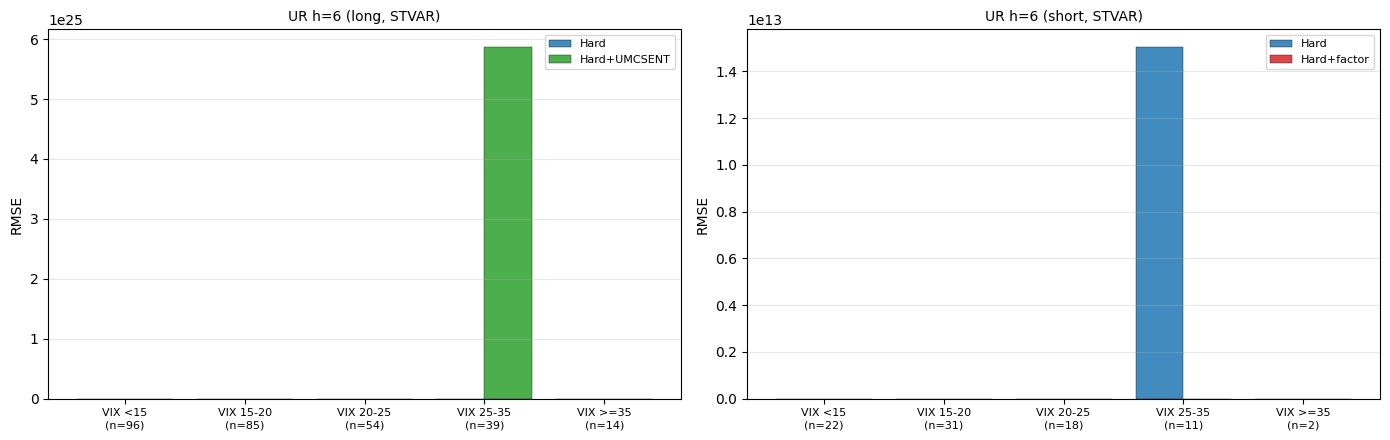

In [5]:
def rmse_by_bin(res, target, horizon, specs):
    m = res[res.ok].copy().merge(vix_m.rename('vx'), left_on='origin', right_index=True, how='left')
    m['bin'] = pd.cut(m['vx'], [0,15,20,25,35,200], labels=['<15','15-20','20-25','25-35','>=35'])
    sub = m[(m.target==target)&(m.horizon==horizon)].copy(); sub['se']=sub['error']**2
    tab = sub.groupby(['bin','spec'],observed=True)['se'].mean().pow(0.5).unstack('spec')
    n = sub.groupby('bin',observed=True).size()//sub.spec.nunique()
    return tab[[s for s in specs if s in tab.columns]], n

COL = {'hard_only':'#1f77b4','hard_plus_umcsent':'#2ca02c','hard_plus_soft_factor':'#d62728'}
LAB = {'hard_only':'Hard','hard_plus_umcsent':'Hard+UMCSENT','hard_plus_soft_factor':'Hard+factor'}

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for ax,(tgt,specs,res,title) in zip(axes,[
    ('unemployment',['hard_only','hard_plus_umcsent'],stvar_long,'UR h=6 (long, STVAR)'),
    ('unemployment',['hard_only','hard_plus_soft_factor'],stvar_short,'UR h=6 (short, STVAR)')]):
    tab,n = rmse_by_bin(res,tgt,6,specs)
    x=np.arange(len(tab)); bw=0.8/len(specs)
    for si,sp in enumerate(specs):
        ax.bar(x+(si-(len(specs)-1)/2)*bw, tab[sp].values, bw, color=COL[sp], alpha=0.85, label=LAB[sp], edgecolor='black', linewidth=0.3)
    ax.set_xticks(x); ax.set_xticklabels([f'VIX {b}\n(n={int(n.loc[b])})' for b in tab.index], fontsize=8)
    ax.set_ylabel('RMSE'); ax.set_title(title, fontsize=10); ax.legend(fontsize=8); ax.grid(axis='y',alpha=0.3)
plt.tight_layout(); plt.show()

## Takeaways — the STVAR as specified FAILS (explosive forecasts)

**Do not trust the RMSE / GW numbers in sections 2–4 above. They are dominated by explosive forecasts and are reported here only to document the failure.**

1. **The forecasts explode at exactly the high-stress origins.** Hard-only unemployment h=12 RMSE is order **1e25** (section 2). 19 of 288 long-window origins diverge, and every one of them is in the 2008–09 GFC or 2020 COVID window — i.e. the high-VIX origins on which the whole regime-conditional test depends. The other ~93% of origins are fine.

2. **Why it explodes.** With frozen-regime forecasting, an origin with `G_origin ≈ 1` iterates the *combined* AR block (low + high). That combined block is estimated off very few high-stress observations (~12 GFC months once COVID is removed by the dummy) and is **not stationarity-constrained**, so the spectral radius of its companion matrix exceeds 1 and the 12-step iterated path diverges.

3. **The `soft_imp_% = 100` / `1e29` entries are artifacts.** They are ratios between explosive hard and explosive soft forecasts, not a real soft-data advantage. No soft-vs-hard conclusion can be drawn from this run.

4. **The grid also pins the threshold at the `c = 2.0` corner** for 249/288 origins, so for calm origins the regime is essentially off (`G_origin ≈ 0`) and the model is just the linear dummy VAR; for the few stress origins it is on and explodes. Neither mode delivers a usable regime-conditional forecast.

**This is a genuine specification failure, not the paper's answer.** Fixes to try next, in order of cleanliness:
- **Stationarity safeguard:** reject (gamma, c) candidates whose combined high-stress companion matrix is explosive, or shrink the high-stress block toward the low-stress block (a smooth-transition analogue of ridge / Minnesota prior). This is the principled fix.
- **Don't dummy COVID:** let the high-stress regime identify off both 2008 *and* 2020, giving more stress observations to pin down a stationary high-stress block.
- **Markov-switching:** latent regime, no threshold variable, and standard filters impose stationarity per regime.